Import Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [18]:
df = pd.read_csv("/content/climate_data.csv")

Display First 5 Rows

In [19]:
print(df.head())

         Date  Average temperature (°F)  Average humidity (%)  \
0  2009-01-01                      37.8                  35.0   
1  2009-01-02                      43.2                  32.0   
2  2009-01-03                      25.7                  60.0   
3  2009-01-04                       9.3                  67.0   
4  2009-01-05                      23.5                  30.0   

   Average dewpoint (°F)  Average barometer (in)  Average windspeed (mph)  \
0                   12.7                    29.7                     26.4   
1                   14.7                    29.5                     12.8   
2                   12.7                    29.7                      8.3   
3                    0.1                    30.4                      2.9   
4                   -5.3                    29.9                     16.7   

   Average gustspeed (mph)  Average direction (°deg)  Rainfall for month (in)  \
0                     36.8                     274.0             

Dataset Information

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      3902 non-null   object 
 1   Average temperature (°F)  3902 non-null   float64
 2   Average humidity (%)      3902 non-null   float64
 3   Average dewpoint (°F)     3902 non-null   float64
 4   Average barometer (in)    3902 non-null   float64
 5   Average windspeed (mph)   3902 non-null   float64
 6   Average gustspeed (mph)   3902 non-null   float64
 7   Average direction (°deg)  3902 non-null   float64
 8   Rainfall for month (in)   3902 non-null   float64
 9   Rainfall for year (in)    3902 non-null   float64
 10  Maximum rain per minute   3902 non-null   float64
 11  Maximum temperature (°F)  3902 non-null   float64
 12  Minimum temperature (°F)  3902 non-null   float64
 13  Maximum humidity (%)      3902 non-null   float64
 14  Minimum 

Check Missing Values

In [21]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date                        0
Average temperature (°F)    0
Average humidity (%)        0
Average dewpoint (°F)       0
Average barometer (in)      0
Average windspeed (mph)     0
Average gustspeed (mph)     0
Average direction (°deg)    0
Rainfall for month (in)     0
Rainfall for year (in)      0
Maximum rain per minute     0
Maximum temperature (°F)    0
Minimum temperature (°F)    0
Maximum humidity (%)        0
Minimum humidity (%)        0
Maximum pressure            0
Minimum pressure            0
Maximum windspeed (mph)     0
Maximum gust speed (mph)    0
Maximum heat index (°F)     0
Date1                       0
Month                       0
diff_pressure               0
dtype: int64


Fill Missing Values with Mean

In [22]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Convert Date Column to Datetime

In [23]:
df['Date'] = pd.to_datetime(df['Date'])

Basic Statistics

In [24]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
                                Date  Average temperature (°F)  \
count                           3902               3902.000000   
mean   2014-11-25 00:33:12.824192768                 44.670733   
min              2009-01-01 00:00:00                -12.100000   
25%              2012-03-03 06:00:00                 33.700000   
50%              2014-12-26 12:00:00                 45.100000   
75%              2017-10-09 18:00:00                 58.000000   
max              2020-07-28 00:00:00                 76.300000   
std                              NaN                 15.326793   

       Average humidity (%)  Average dewpoint (°F)  Average barometer (in)  \
count           3902.000000            3902.000000             3902.000000   
mean              48.878011              23.127037               29.881420   
min                9.000000             -22.200000               28.200000   
25%               36.000000              12.100000               29.

Create Season Column

In [25]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Date'].dt.month.apply(get_season)

Visualization

Line Plot – Temperature Trend

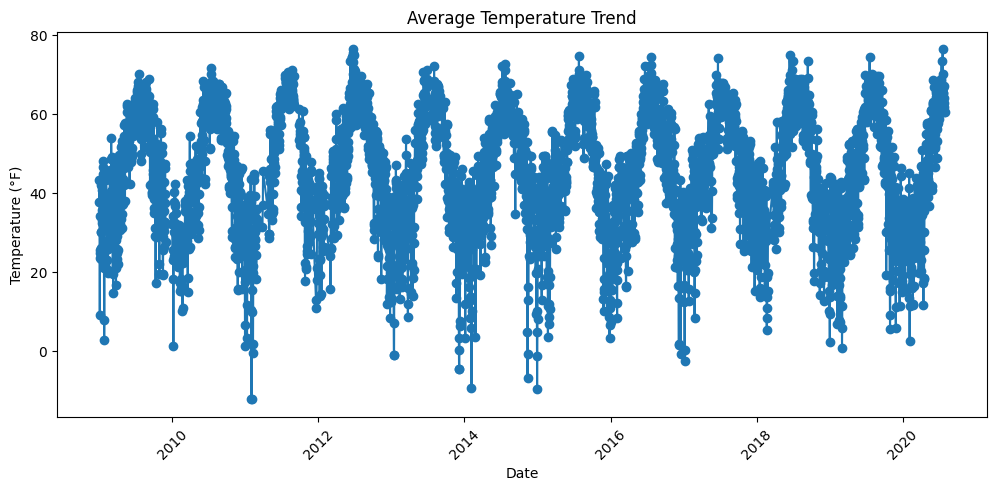

In [26]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Average temperature (°F)'], marker='o')

plt.title("Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=45)

plt.show()

Bar Chart – Seasonal Rainfall

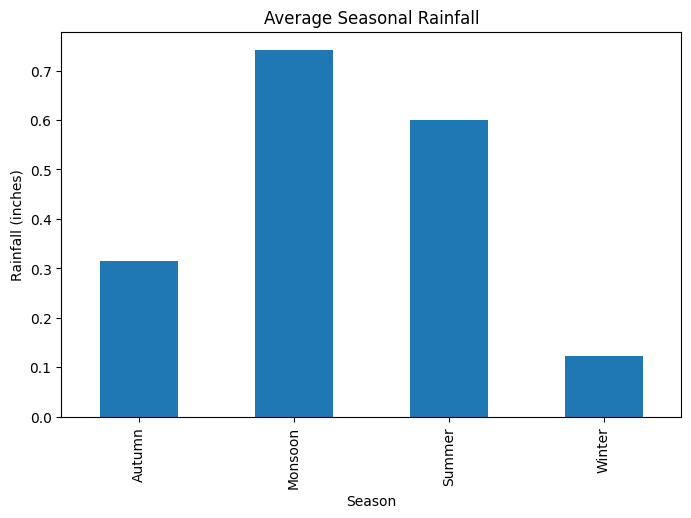

In [27]:
seasonal_rainfall = df.groupby('Season')['Rainfall for month (in)'].mean()

plt.figure(figsize=(8,5))
seasonal_rainfall.plot(kind='bar')

plt.title("Average Seasonal Rainfall")
plt.xlabel("Season")
plt.ylabel("Rainfall (inches)")

plt.show()

Histogram – Temperature Distribution

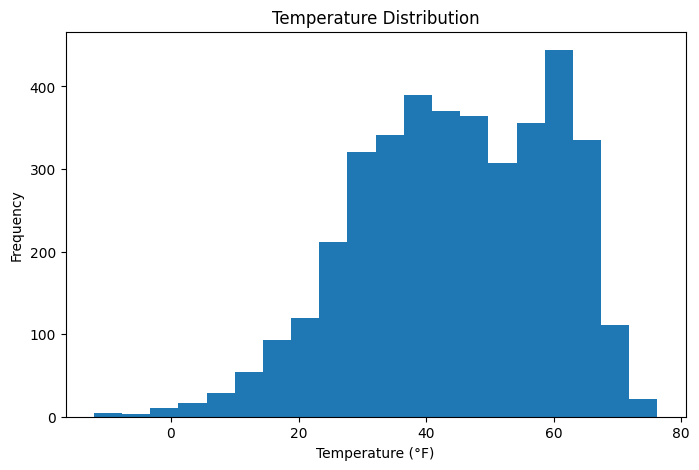

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Average temperature (°F)'],
    bins=20
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")

plt.show()

Scatter Plot – Temperature vs Humidity

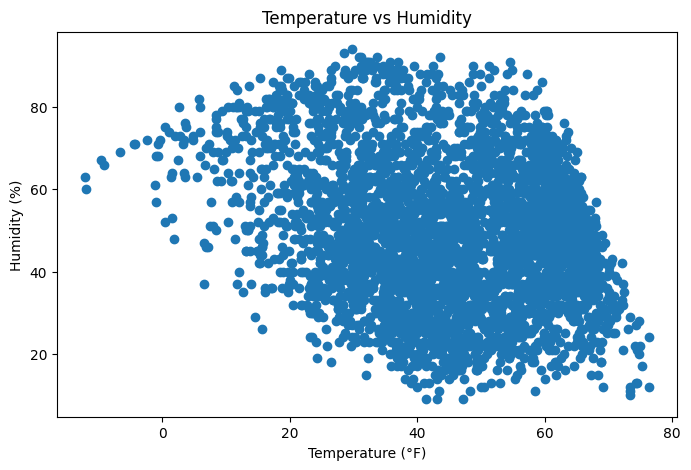

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Average temperature (°F)'],
    df['Average humidity (%)']
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°F)")
plt.ylabel("Humidity (%)")

plt.show()

Pie Chart – Seasonal Distribution

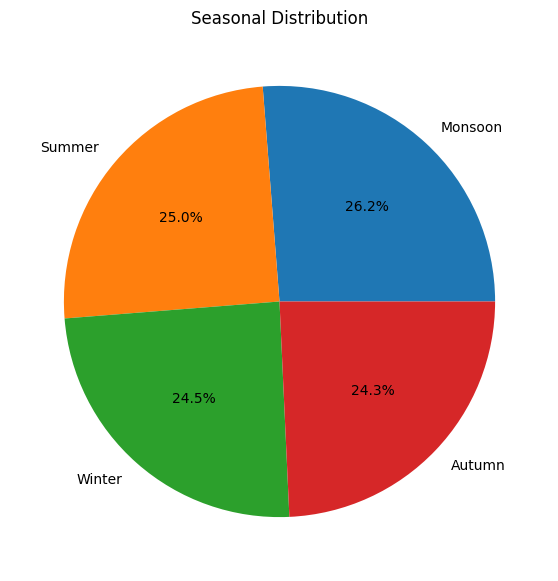

In [30]:
season_count = df['Season'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    season_count,
    labels=season_count.index,
    autopct='%1.1f%%'
)

plt.title("Seasonal Distribution")

plt.show()

Heatmap – Correlation Analysis

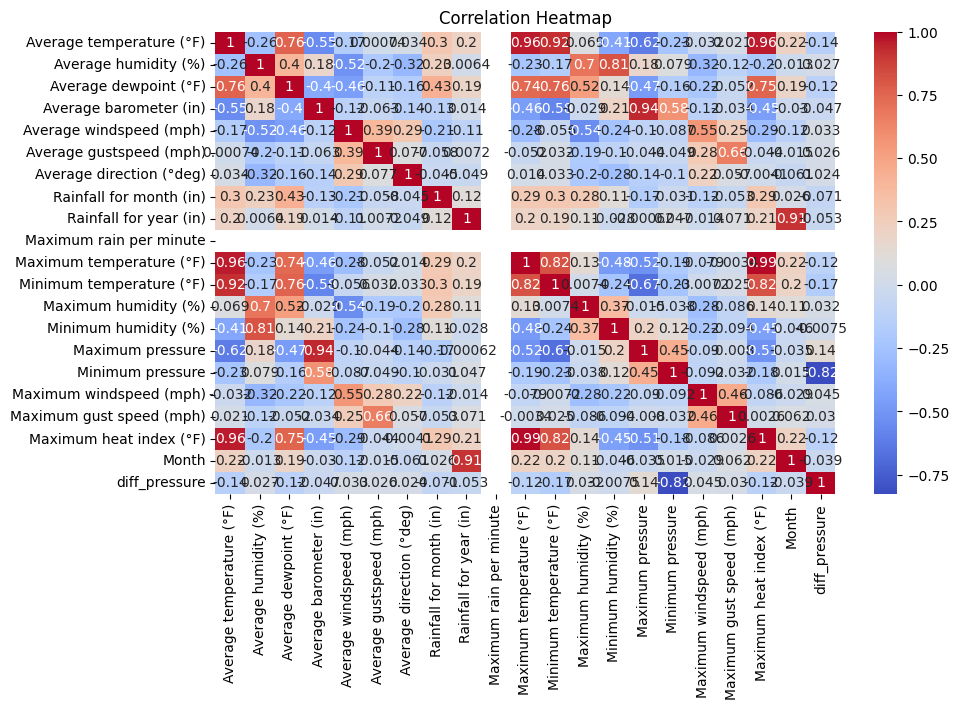

In [31]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()